# Naive Bayes Predictive Model in Detecting Fraud in Online Transaction Data

Train, Tune and evaluate a Naive Bayes Model to predict `is_fraud` using `feature_engineered_with_SLM.csv`.

**Objective:**
- To train, tune, and evaluate a Naive Bayes model for detecting fraudulent online transactions.
- The model predicts the binary target variable `is_fraud`.
- This model will later be compared against a Decision Tree baseline using the same dataset and preprocessing steps.

#### Import Library, Model and Dataset

This section:
- Imports essential Python libraries 
- Imports Naive Bayes model
- Loads the processed dataset 
- Defines the target variable (`is_fraud`) for fraud detection.
- Performs basic dataset inspection, including shape and fraud class distribution, to understand class imbalance.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

# Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

RANDOM_SEED = 42

# Load dataset
df = pd.read_csv('../data/processed/feature_engineered_with_SLM.csv')
display(df.head())

# Define target column
target_col = "is_fraud"
print("Target column:", target_col)
print("Dataset shape:", df.shape)
print("Fraud rate:", df[target_col].mean())
display(df[target_col].value_counts(dropna=False).to_frame("count"))

,transaction_id,customer_id,transaction_datetime,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,...,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,998,1000,2022-10-05 15:13:00,US,mobile_app,luxury,672.47,23.0,2,3,...,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,953,1000,2023-02-05 06:18:18,US,web,gaming,2593.31,84.0,0,0,...,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,94,1000,2023-03-23 18:04:02,US,pos_terminal,electronics,302.22,70.0,3,1,...,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2
3,457,1000,2023-04-05 00:14:27,US,mobile_app,gaming,4395.07,24.0,0,2,...,1,2,1931.283333,1662.07937,1.482352,0,1,0,7.333333,2
4,1199,1000,2023-07-13 02:02:46,US,mobile_app,luxury,579.99,23.0,1,0,...,1,2,1931.283333,1662.07937,-0.813014,0,1,0,5.555556,0


Target column: is_fraud
Dataset shape: (1200, 33)
Fraud rate: 0.0675


,count
is_fraud,
0,1119
1,81


### Define Features to Avoid Leakage

This section:
- Identifies columns that must be excluded to prevent data leakage, such as:
  - Unique identifiers (e.g., transaction and customer IDs)
  - Raw timestamps already transformed into engineered features
  - Raw transaction text already processed using SLM features
- Drops fully missing or non-informative features.
- Separates the dataset into:
  - Feature matrix `X`
  - Target vector `y`
- Ensures only valid predictive features are used for model training.

In [2]:
# Columns to drop
DROP_COLS = [
    "transaction_id",
    "customer_id",
    "transaction_datetime",
    "prev_txn_time",
    "transaction_note",
    "txn_7d_count"   # fully missing
]

# Drop unnecessary columns
existing_drop = [c for c in DROP_COLS if c in df.columns]
print("Dropping columns:", existing_drop)

X = df.drop(columns=[target_col] + existing_drop, errors="ignore")
y = df[target_col].astype(int)

display(X.head())
print("Feature set shape:", X.shape)

Dropping columns: ['transaction_id', 'customer_id', 'transaction_datetime', 'prev_txn_time', 'transaction_note', 'txn_7d_count']


,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,slm_risk_score,slm_urgency,slm_anomaly_category,...,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,US,mobile_app,luxury,672.47,23.0,2,3,9,high,fraud,...,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,US,web,gaming,2593.31,84.0,0,0,8,high,fraud,...,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,US,pos_terminal,electronics,302.22,70.0,3,1,9,high,fraud,...,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2
3,US,mobile_app,gaming,4395.07,24.0,0,2,9,high,fraud,...,1,2,1931.283333,1662.07937,1.482352,0,1,0,7.333333,2
4,US,mobile_app,luxury,579.99,23.0,1,0,5,low,unknown,...,1,2,1931.283333,1662.07937,-0.813014,0,1,0,5.555556,0


Feature set shape: (1200, 26)


### Splitting Training & Testing Data

This section:
- Splits the dataset into training (80%) and testing (20%) sets.
- Uses stratified sampling to preserve the fraud class distribution in both sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train shape: (960, 26)
Test shape: (240, 26)
Train fraud rate: 0.06770833333333333
Test fraud rate: 0.06666666666666667


### Preprocessing Pipeline

This section:
- Applies preprocessing steps:
  - Numeric features:
    - Median imputation to handle missing values robustly.
  - Categorical features:
    - Most-frequent imputation for missing categories.
    - One-hot encoding to convert categorical variables into numeric format.
- Combines all preprocessing steps using a `ColumnTransformer`.

In [4]:
# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Define transformers for preprocessing
# Note: Gaussian NB works better with scaled features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine transformers into a ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

Numeric columns: ['amount', 'device_trust_score', 'num_txn_24h_customer', 'previous_chargeback_count', 'slm_risk_score', 'txn_hour', 'txn_dayofweek', 'txn_week', 'is_weekend', 'is_night', 'txn_gap_minutes', 'txn_hour_count', 'txn_dayofweek_count', 'customer_mean_amount', 'customer_std_amount', 'amount_z_customer', 'is_risky_country', 'low_device_trust', 'high_amount_z', 'composite_risk_score', 'urgency_numeric']
Categorical columns: ['country', 'channel', 'merchant_category', 'slm_urgency', 'slm_anomaly_category']


### Naive Bayes Baseline Pipeline

This section:
- Defines a baseline Naive Bayes classifier with:
  - Multiple decision trees (`n_estimators`)
  - Balanced class weights to address fraud class imbalance
- Wraps preprocessing and model training into a single pipeline.
- Serves as an initial benchmark before hyperparameter tuning.

In [5]:
# Define Naive Bayes model pipeline
nb_baseline = GaussianNB()

nb_baseline_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", nb_baseline)
])

### Train & Evaluate Baseline NB

This section:
- Trains the Naive Bayes baseline model using the training dataset.
- Generates:
  - Class predictions (`y_pred`)
  - Fraud probabilities (`y_proba`)
- Evaluates model performance using metrics suitable for imbalanced data:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC
  - Precision–Recall AUC
- Displays a classification report to assess fraud and non-fraud detection performance.


In [6]:
# Train Naive Bayes baseline model
nb_baseline_pipe.fit(X_train, y_train)

y_pred = nb_baseline_pipe.predict(X_test)
y_proba = nb_baseline_pipe.predict_proba(X_test)[:, 1]

# Evaluate model
nb_metrics = {
    "model": "NaiveBayes_baseline",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
}

display(pd.DataFrame([nb_metrics]))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,NaiveBayes_baseline,0.825,0.035714,0.0625,0.045455,0.472656,0.067635



Classification report:
              precision    recall  f1-score   support

           0     0.9292    0.8795    0.9037       224
           1     0.0357    0.0625    0.0455        16

    accuracy                         0.8250       240
   macro avg     0.4825    0.4710    0.4746       240
weighted avg     0.8697    0.8250    0.8465       240



### Model Evaluation Visualizations (Baseline NB)

This section:
- Visualizes model performance using:
  - Confusion matrix to inspect classification errors.
  - ROC curve to evaluate overall discriminative ability.
  - Precision–Recall curve to assess performance on the minority fraud class.

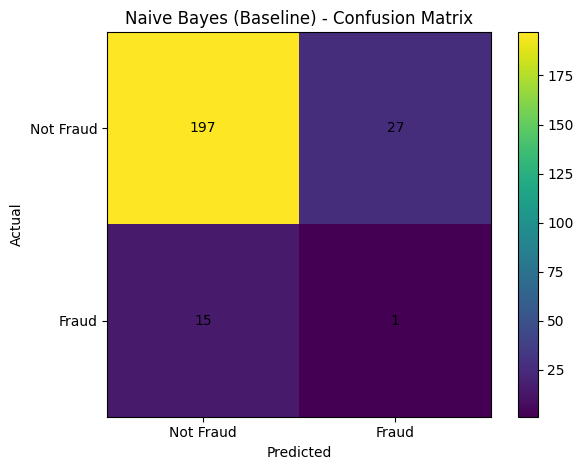

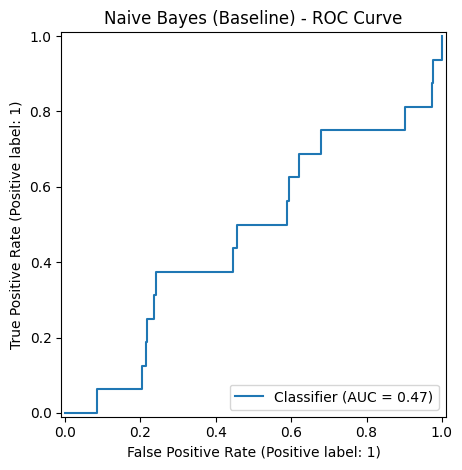

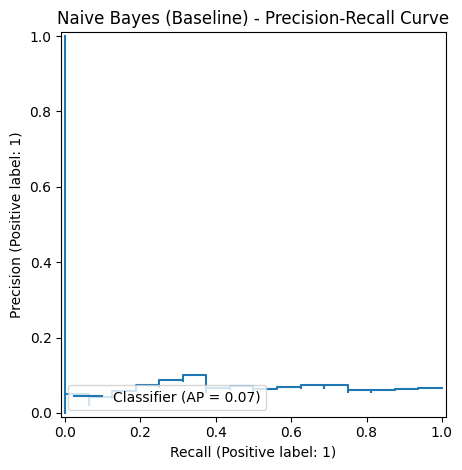

In [7]:
# make output directories for figures and tables
OUTPUT_DIR = "../outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
NB_FIG_DIR = os.path.join(FIG_DIR, "naive_bayes")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(NB_FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)


# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Naive Bayes (Baseline) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha="center", va="center")

plt.tight_layout()
plt.savefig(
    os.path.join(NB_FIG_DIR, "nb_baseline_confusion_matrix.png"),
    dpi=200
)
plt.show()

# Plot ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Naive Bayes (Baseline) - ROC Curve")
plt.tight_layout()
plt.savefig(
    os.path.join(NB_FIG_DIR, "nb_baseline_roc_curve.png"),
    dpi=200
)
plt.show()

# Plot Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Naive Bayes (Baseline) - Precision-Recall Curve")
plt.tight_layout()
plt.savefig(
    os.path.join(NB_FIG_DIR, "nb_baseline_pr_curve.png"),
    dpi=200
)
plt.show()

### Naive Bayes Tuning with Prior Adjustment

This section:
- Performs controlled hyperparameter tuning using GridSearchCV.
- Tunes key Gaussian Naive Bayes parameters, icnluding:
  - Variance smoothing `var_smooting`
  - Class prior prob `priors`
- Uses stratified 5-fold cross-validation to preserve class distribution across folds.
- Optimizes the F1-score to balance precision and recall for imbalanced data.

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define pipeline (assuming nb_baseline_pipe is Pipeline with 'model' step)
# You can tune both var_smoothing and class priors
param_grid = {
    "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
    "model__priors": [
        [0.5, 0.5],   # equal weighting
        [0.7, 0.3],   # favor majority
        [0.3, 0.7],   # favor minority
        [0.1, 0.9],   # heavily favor minority
    ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid = GridSearchCV(
    estimator=nb_baseline_pipe,
    param_grid=param_grid,
    scoring="f1",   # optimize for F1 to balance recall & precision
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__priors': [0.5, 0.5], 'model__var_smoothing': 1e-05}
Best CV F1: 0.15843975843975844


### Evaluate Tuned Naive Bayes

This section:
- Evaluates the best-performing NB model identified during tuning.
- Computes the same evaluation metrics as the baseline model for fair comparison.


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,NaiveBayes_tuned,0.65,0.075,0.375,0.125,0.472656,0.067635



Classification report (Tuned Naive Bayes):
              precision    recall  f1-score   support

           0     0.9375    0.6696    0.7812       224
           1     0.0750    0.3750    0.1250        16

    accuracy                         0.6500       240
   macro avg     0.5062    0.5223    0.4531       240
weighted avg     0.8800    0.6500    0.7375       240



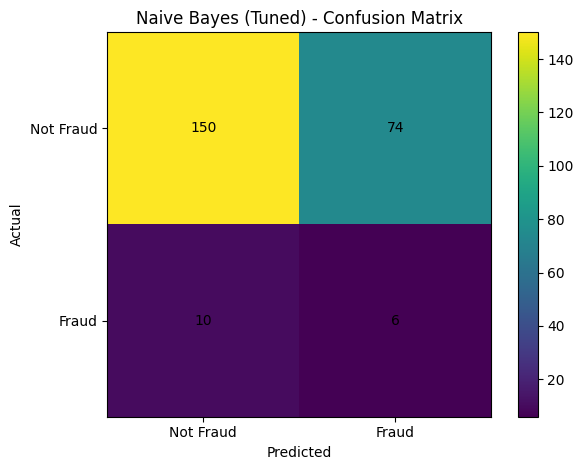

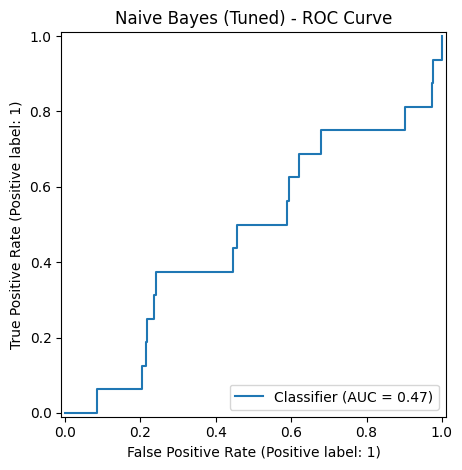

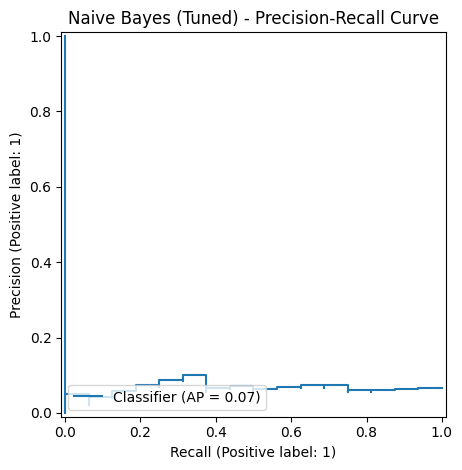

In [9]:
# Evaluate the best model from GridSearchCV
best_nb = grid.best_estimator_

y_pred_tuned = best_nb.predict(X_test)
y_proba_tuned = best_nb.predict_proba(X_test)[:, 1]

# Evaluate tuned model
nb_metrics_tuned = {
    "model": "NaiveBayes_tuned",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_tuned),
    "pr_auc": average_precision_score(y_test, y_proba_tuned),
}

display(pd.DataFrame([nb_metrics_tuned]))


# Classification report for tuned NB model
print("\nClassification report (Tuned Naive Bayes):")
print(classification_report(y_test, y_pred_tuned, digits=4))

# Confusion matrix (Tuned NB)
cm2 = confusion_matrix(y_test, y_pred_tuned)

plt.figure()
plt.imshow(cm2)
plt.title("Naive Bayes (Tuned) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])
for (i, j), val in np.ndenumerate(cm2):
    plt.text(j, i, int(val), ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(NB_FIG_DIR, "nb_tuned_confusion_matrix.png"), dpi=200)
plt.show()

# ROC curve (Tuned NB)
RocCurveDisplay.from_predictions(y_test, y_proba_tuned)
plt.title("Naive Bayes (Tuned) - ROC Curve")
plt.tight_layout()
plt.savefig(os.path.join(NB_FIG_DIR, "nb_tuned_roc_curve.png"), dpi=200)
plt.show()

# Precision-Recall curve (Tuned NB)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_tuned)
plt.title("Naive Bayes (Tuned) - Precision-Recall Curve")
plt.tight_layout()
plt.savefig(os.path.join(NB_FIG_DIR, "nb_tuned_pr_curve.png"), dpi=200)
plt.show()

### Feature Importance Analysis (Naive Bayes)

This section:
- Retrieves feature importance scores from the tuned NB model.
- Identifies the most influential features (15) contributing to fraud detection.

,feature,mean_difference
1,device_trust_score,0.437966
19,composite_risk_score,0.334460
17,low_device_trust,0.316266
3,previous_chargeback_count,0.296927
5,txn_hour,0.293037
9,is_night,0.286218
7,txn_week,0.216433
0,amount,0.130830
32,merchant_category_electronics,0.128664
4,slm_risk_score,0.125848


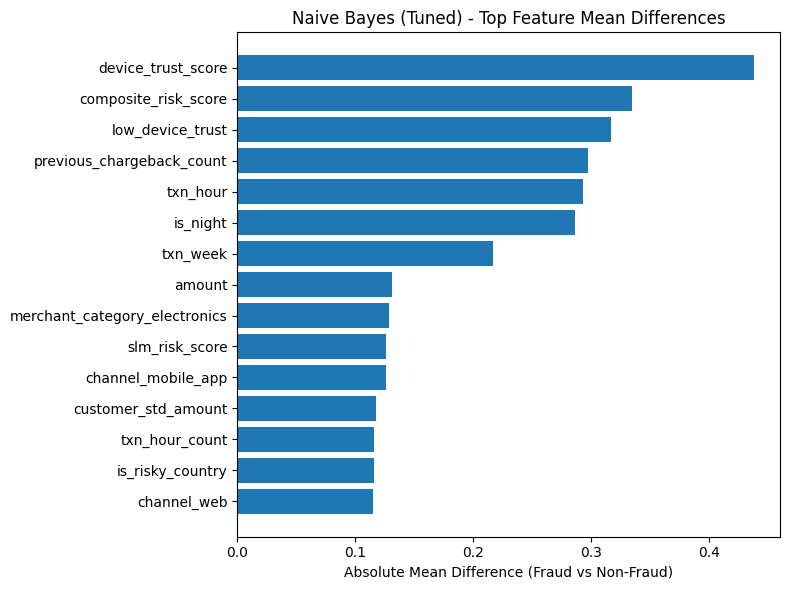

Number of features: 44
Class priors: [0.5 0.5]
Var smoothing: 1e-05


In [10]:
# Helper: get feature names after ColumnTransformer (incl. one-hot)
def get_feature_names(preprocessor: ColumnTransformer) -> list[str]:
    feat_names = []

    # numeric
    if "num" in preprocessor.named_transformers_:
        feat_names.extend(numeric_cols)

    # categorical (one-hot)
    if "cat" in preprocessor.named_transformers_:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(categorical_cols).tolist()
        feat_names.extend(ohe_names)

    return feat_names

# Feature analysis from the tuned Naive Bayes model
# Note: Naive Bayes doesn't have feature_importances_ like tree-based models
# Instead, we  look at the mean and variance per class
pre = best_nb.named_steps["preprocess"]
model = best_nb.named_steps["model"]

feat_names = get_feature_names(pre)

# Get class means (theta_) and variances (var_)
# theta_ shape: [n_classes, n_features]
# var_ shape: [n_classes, n_features]

# Calculate the absolute difference in means between classes as a proxy for importance
if hasattr(model, 'theta_'):
    mean_diff = np.abs(model.theta_[1] - model.theta_[0])  # Fraud vs Non-fraud
    
    fi_nb = (
        pd.DataFrame({"feature": feat_names, "mean_difference": mean_diff})
        .sort_values("mean_difference", ascending=False)
    )
    
    display(fi_nb.head(15))
    
    # Plot top 15 features by mean difference
    plt.figure(figsize=(8, 6))
    plt.barh(
        fi_nb.head(15)["feature"][::-1],
        fi_nb.head(15)["mean_difference"][::-1]
    )
    plt.title("Naive Bayes (Tuned) - Top Feature Mean Differences")
    plt.xlabel("Absolute Mean Difference (Fraud vs Non-Fraud)")
    plt.tight_layout()
    plt.savefig(os.path.join(NB_FIG_DIR, "nb_tuned_feature_analysis_top15.png"), dpi=200)
    plt.show()
    
    # Print model parameters
    print("Number of features:", len(feat_names))
    print("Class priors:", model.class_prior_)
    print("Var smoothing:", model.var_smoothing)
    
    # save feature analysis to CSV
    fi_nb.to_csv(os.path.join(TAB_DIR, "nb_feature_analysis.csv"), index=False)

### Saving Metrics for model comparison

This section:
- Aggregates baseline and tuned NB performance metrics.
- Enables direct comparison with other models

In [11]:
# Save all metrics to CSV
nb_all_metrics = pd.DataFrame([nb_metrics, nb_metrics_tuned])
display(nb_all_metrics)

nb_all_metrics.to_csv(
    os.path.join(TAB_DIR, "nb_metrics.csv"),
    index=False
)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,NaiveBayes_baseline,0.825,0.035714,0.0625,0.045455,0.472656,0.067635
1,NaiveBayes_tuned,0.650,0.075000,0.3750,0.125000,0.472656,0.067635
